# Manipulação de dados

<div class="alert alert-info">
    <b>Informações:</b>
    <details>
        <summary>
            <font>
                <b>São clicaveis</b>
            </font>
        </summary>
  
<ul>
        <li>
            <b>Guardam conteúdo</b>
        </li>
    </ul>
</details>
</div>

In [2]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("dados1.csv", sep=';',header=None)
df.columns= ["A","B","C","D","E",
            "F","G","H","I","J"
]
df

,A,B,C,D,E,F,G,H,I,J
0,"3,5","4,0","5,5","6,0","5,0","5,5","5,0","5,5","4,0","10,0"
1,"6,5","9,5","4,0","7,0","7,5","3,0","4,5","5,0","2,5","6,0"
2,"5,0","6,5","3,5","4,5","8,5","4,0","8,0","7,0","6,0","7,5"
3,"8,5","6,0","9,0","6,0","6,5","7,5","5,5","6,5","8,0","8,5"
4,"4,5","7,5","8,0","3,0","4,0","8,0","4,5","5,5","6,0","6,0"
5,"7,5","3,5","3,0","7,0","1,5","4,5","10,0","5,5","2,5","10,0"
6,"4,0","6,5","7,5","5,5","7,0","7,5","6,0","6,5","6,5","5,5"
7,"6,5","5,0","5,5","7,5","8,0","6,5","5,0","7,0","6,0","5,5"
8,"3,0","5,0","3,5","6,0","6,5","6,0","8,0","5,5","7,5","6,0"
9,"2,5","7,5","9,0","6,0","6,5","3,5","4,5","7,0","5,0","5,0"


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação do pd.read_csv</b>
        </font>
    </summary>

- Leitura dos <b>dados1.csv</b> usando o separador <b>;</b> que é comum em csv do brasil.
- Após isso utilizo o <b>header=None</b> para não colocar nenhum valor nas colunas. 
</details>

In [66]:
notas = df.values.flatten()

<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação do values.flatten</b>
        </font>
    </summary>

- Utilizando o <b>.values</b> é possivel pegar arrays de todas as colunas.
- Após isso utilizo o <b>.flatten()</b> para transformar todos os arrays em um só.
</details>

In [68]:
df_notas = pd.DataFrame({"nota": notas})
df_notas["nota"] = df_notas["nota"].str.replace(",",".").astype(float)
df_notas

,nota
0,3.5
1,4.0
2,5.5
3,6.0
4,5.0
...,...
95,3.5
96,4.5
97,7.0
98,5.0


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação da criação de um novo dataframe</b>
        </font>
    </summary>

- Após criar o dataframe com coluna única de notas, utilizo a mesma para substituição de virgula por ponto com
 <b>.str.replace</b> para assim transformar em float.

</details>

In [71]:
gap = [0, 2, 4, 6, 8, 10]

df_notas["classe"] = pd.cut(df_notas["nota"], bins=gap, right=False)
df_notas

,nota,classe
0,3.5,"[2, 4)"
1,4.0,"[4, 6)"
2,5.5,"[4, 6)"
3,6.0,"[6, 8)"
4,5.0,"[4, 6)"
...,...,...
95,3.5,"[2, 4)"
96,4.5,"[4, 6)"
97,7.0,"[6, 8)"
98,5.0,"[4, 6)"


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação da criação de frequência com o pd.cut</b>
        </font>
    </summary>

- Primeiro crio um array <b>gap</b> para colocar em bins quando for utilizar o pd.cut.
- Eu crio uma coluna nova e utilizo o <b>pd.cut()</b> para transformar a coluna de notas em intervalos.
</details>

In [84]:
df_freq = df_notas["classe"].value_counts().sort_index().reset_index()
df_freq.columns = ["classe", "frequencia"]
df_freq

,classe,frequencia
0,"[0, 2)",1
1,"[2, 4)",12
2,"[4, 6)",32
3,"[6, 8)",40
4,"[8, 10)",12


<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação da criação do df de frequência</b>
        </font>
    </summary>

- Utilizando a coluna de classe do dataframe de notas eu uso o <b>.value_counts</b> para conta a quantidade de vezes que aquele intervalo aparece, além de usar <b>.sort_index e .reset_index()</b> para organizar os valores e resetar os números dos indices.

</details>

<function matplotlib.pyplot.show(close=None, block=None)>

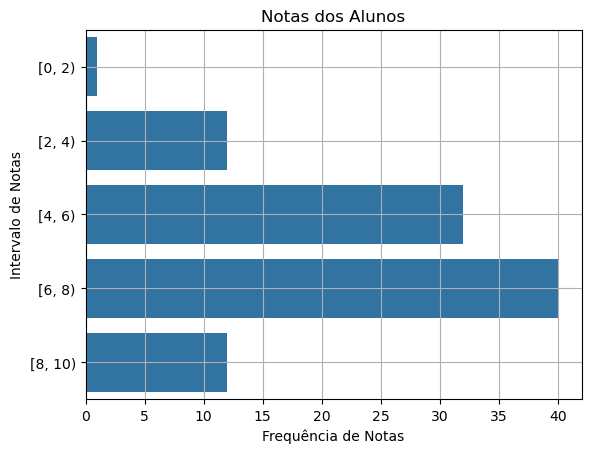

In [87]:
sns.barplot(data=df_freq,x="frequencia",y="classe")

plt.xlabel("Frequência de Notas")
plt.ylabel("Intervalo de Notas")
plt.title("Notas dos Alunos")

plt.grid(True)

plt.show

<details style="color: #b5f877">
    <summary>
        <font style="font-size: 22px;color: #ffffff">
            <b>Explicação da criação do gráfico de barras</b>
        </font>
    </summary>

- Utilizando o seaborn para criar um gráfico de barras com <b>sns.barplot</b> definindo o dataframe <b>df_freq</b> como data.
- Após isso utilizo o <b>xlabel() e ylabel()</b> para alterar o nome dos eixos e <b>title</b> para dar um título ao gráfico.
- Por fim com <b>plt.grid(True)</b> eu adiciono grades para facilitar visualização.
</details>